# Preprocessed Testing Datasets

| [![HOAPS-badge]][HOAPS-url] | [![hplp-badge]][hplp-url] | [![ICON-XPP-badge]][ICON-XPP-url] | [![NextGEMS-badge]][NextGEMS-url] | [![OpenIFS-badge]][OpenIFS-url] |
|:-:|:-:|:-:|:-:|:-:|

[HOAPS-badge]: https://img.shields.io/badge/HOAPS-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[hplp-badge]: https://img.shields.io/badge/hplp-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[ICON-XPP-badge]: https://img.shields.io/badge/ICON--XPP-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[NextGEMS-badge]: https://img.shields.io/badge/NextGEMS-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[OpenIFS-badge]: https://img.shields.io/badge/OpenIFS-grey?style=for-the-badge&logo=readthedocs&logoColor=white

[HOAPS-url]: https://climatedataguide.ucar.edu/climate-data/hoaps-hamburg-ocean-atmosphere-parameters-and-fluxes-satellite-data
[hplp-url]: https://apps.ecmwf.int/ifs-experiments/rd/hplp/
[ICON-XPP-url]: https://doi.org/10.5194/gmd-18-9385-2025
[NextGEMS-url]: https://easy.gems.dkrz.de/DYAMOND/NextGEMS/index.html
[OpenIFS-url]: https://confluence.ecmwf.int/spaces/OIFS/overview

We provide several datasets for this compression laboratory, which are introduced in this folder. We also include small testing subsets for each dataset, which have all been preprocessed to be in NetCDF4 format and on a regular latitude-longitude grid.

This notebook focuses on the small testing datasets. Please see the other notebooks for the original datasets and instructions [^report].

Here, we load all datasets using `xarray` and visualise them using our `quickplot(da)` helper function.

[^report]: Faghih-Naini, S., Tyree, J., Yepes-Arbós, X., Karsten, P. G., Dueben, P., & Järvinen, H. J. (2025). ESiWACE3 Deliverable D3.3 - Report on the online version of the data sets. *Zenodo*. Available from: [doi:10.5281/zenodo.14622238](https://doi.org/10.5281/zenodo.14622238).

In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
from pathlib import Path

import humanize
import netCDF4
import numpy as np
import xarray as xr

In [3]:
data = Path("..", "data").resolve()

In [4]:
import earthkit.plots

from utils import quickplot

In [5]:
DATASET_PATHS = [
    data / "HOAPS" / "HOAPS_2020-08_6-hourly.nc",
    data / "ICON-XPP" / "ICONXPP_regridded_t_025deg_steps_2026-05_06.nc",
    data / "ICON-XPP" / "ICONXPP_regridded_tp_025deg_steps_2026-05_06.nc",
    data / "NextGEMS_EW3_ICON_ngc4008" / "NextGEMS_regridded_hus_025deg_steps_44_45.nc",
    data / "NextGEMS_EW3_ICON_ngc4008" / "NextGEMS_regridded_pr_025deg_steps_44_45.nc",
    data / "OpenIFS" / "OpenIFS_pl_regridded_q_025deg_steps_114_120_levels_100_1000.nc",
    data / "OpenIFS" / "OpenIFS_sfc_regridded_t_025deg_steps_114_120.nc",
    data / "OpenIFS" / "OpenIFS_sfc_regridded_tp_025deg_steps_114_120.nc",
    data / "hplp" / "hplp_ml_regridded_q_025deg_levels_10_137_steps_228_240.nc",
    data / "hplp" / "hplp_sfc_regridded_t_025deg_levels_steps_204_216_228_240.nc",
    data / "hplp" / "hplp_sfc_regridded_t_025deg_steps_228_240.nc",
    data / "hplp" / "hplp_sfc_regridded_tp_025deg_steps_228_240.nc",
]

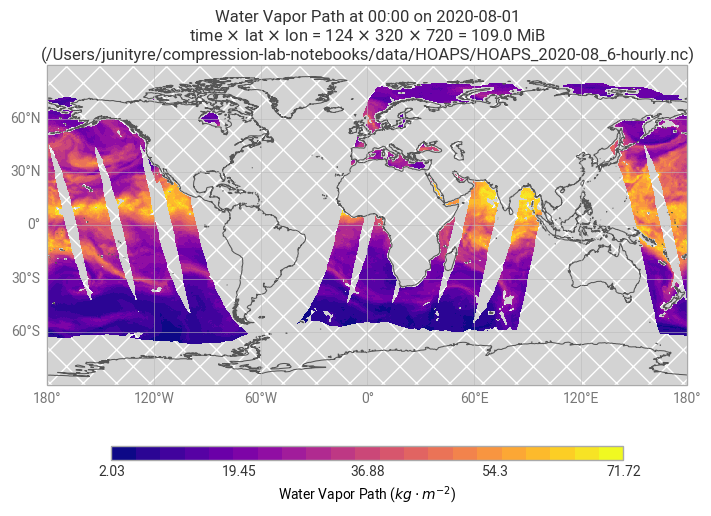

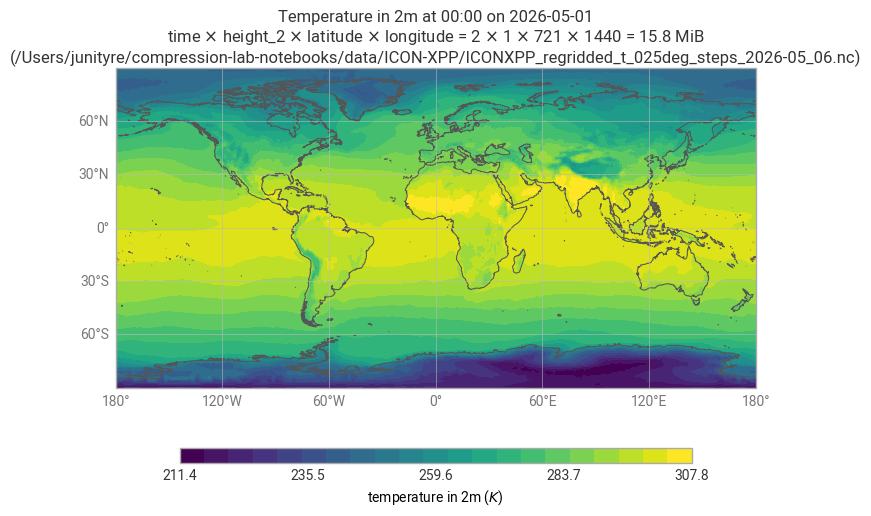

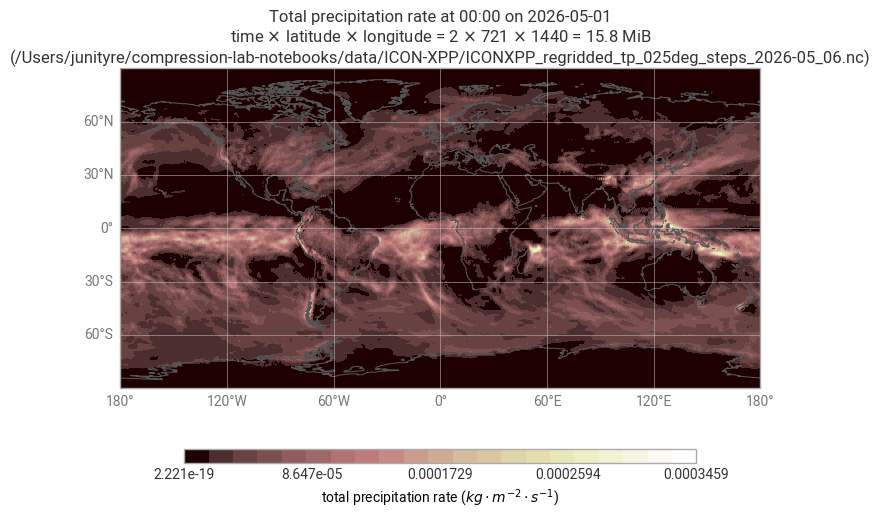

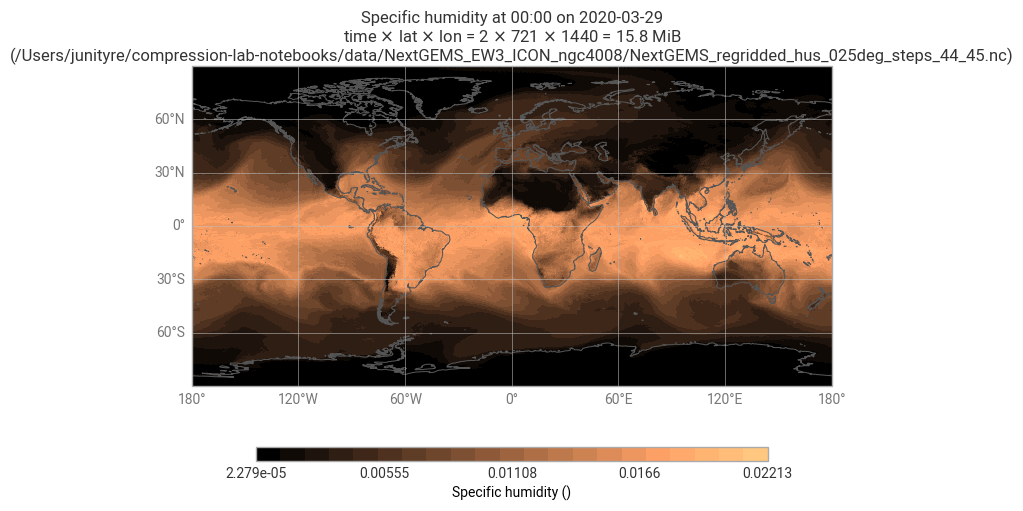

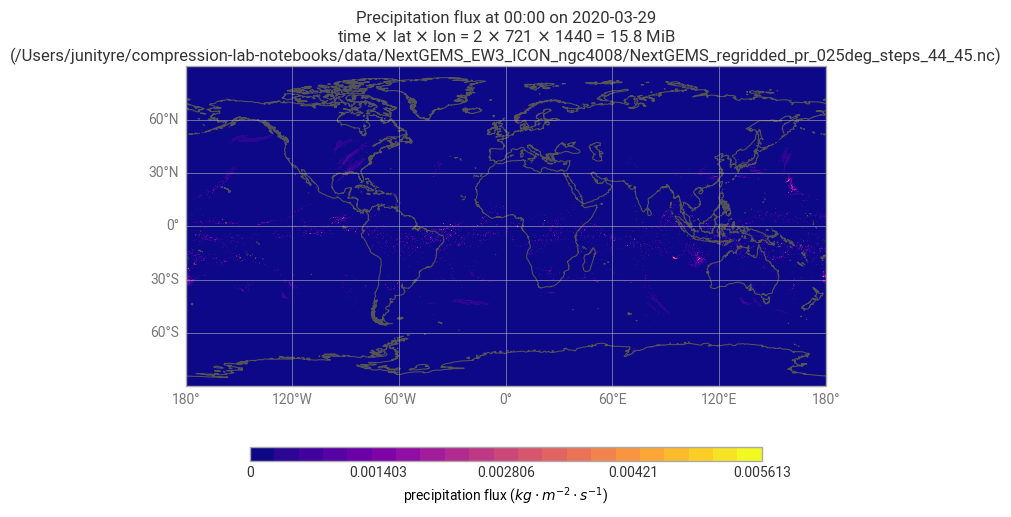

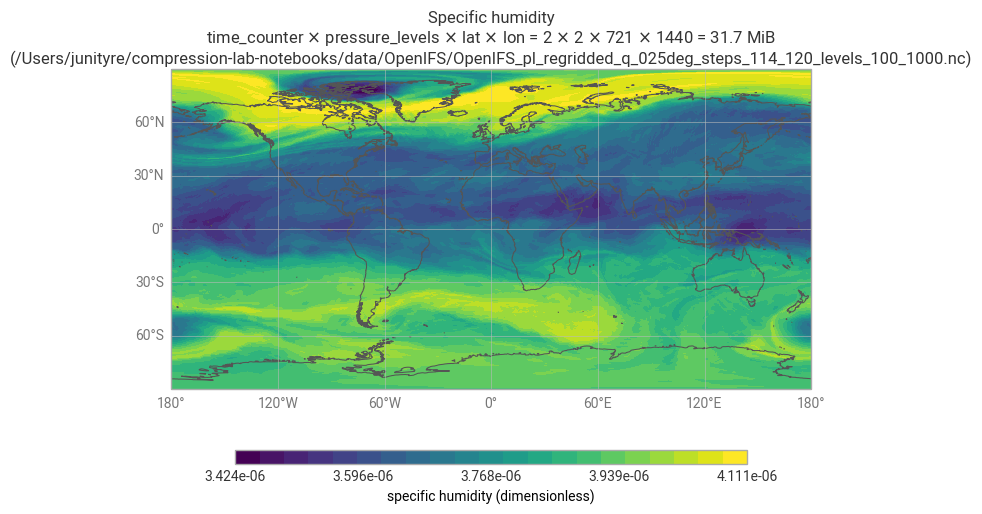

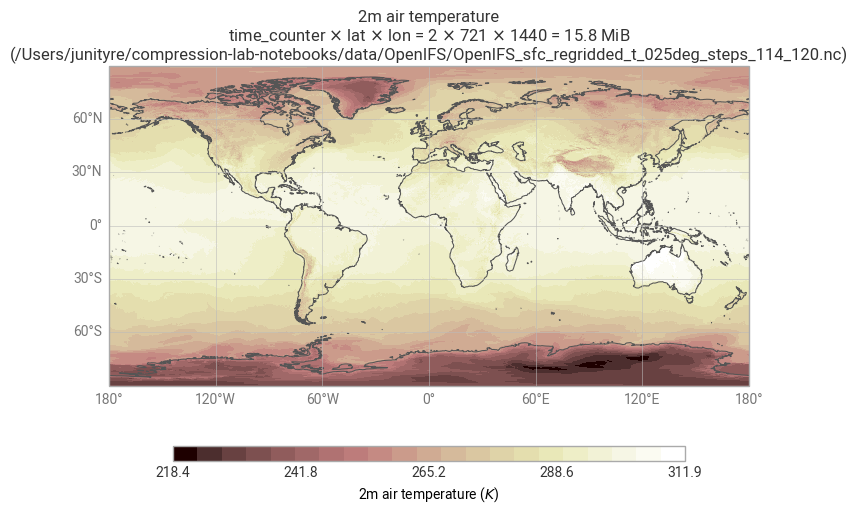

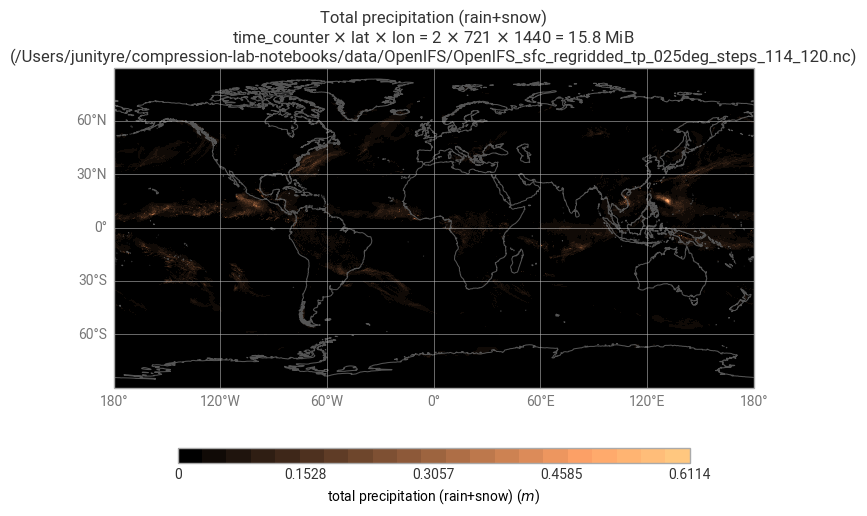

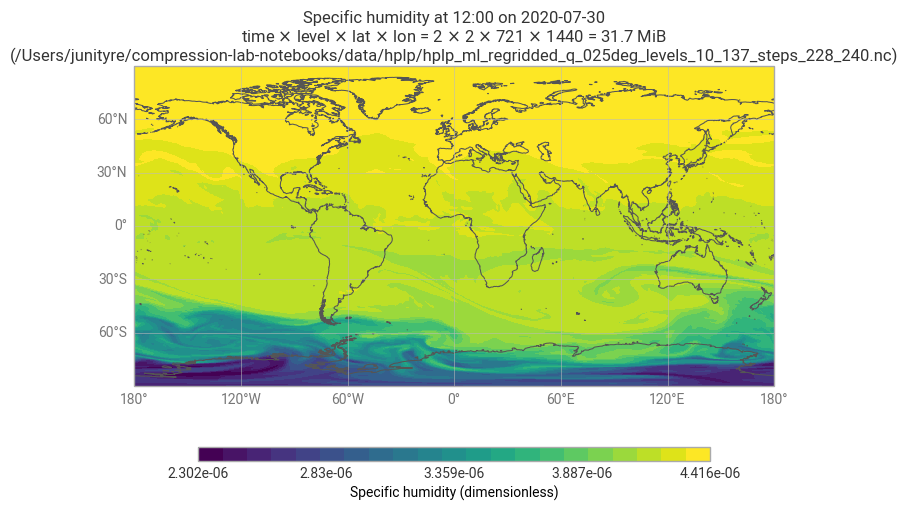

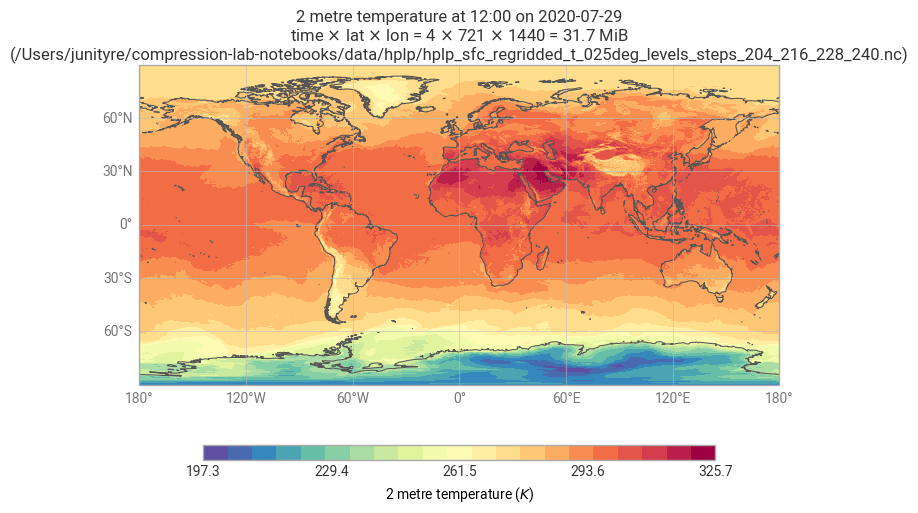

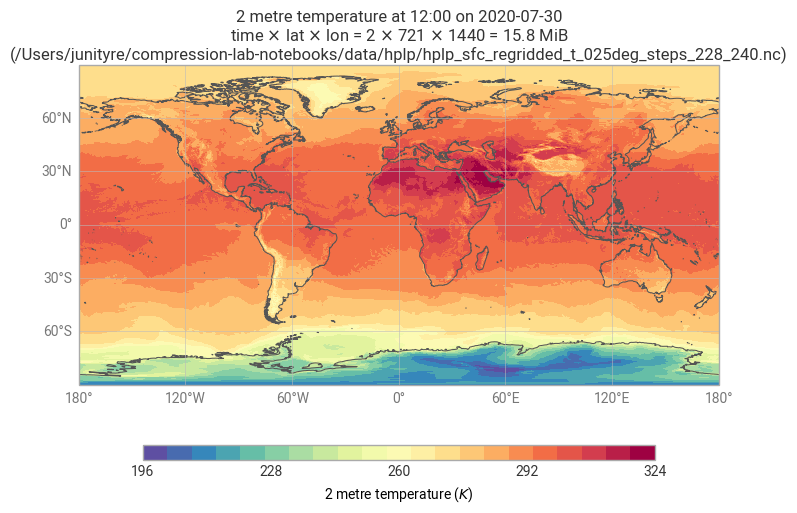

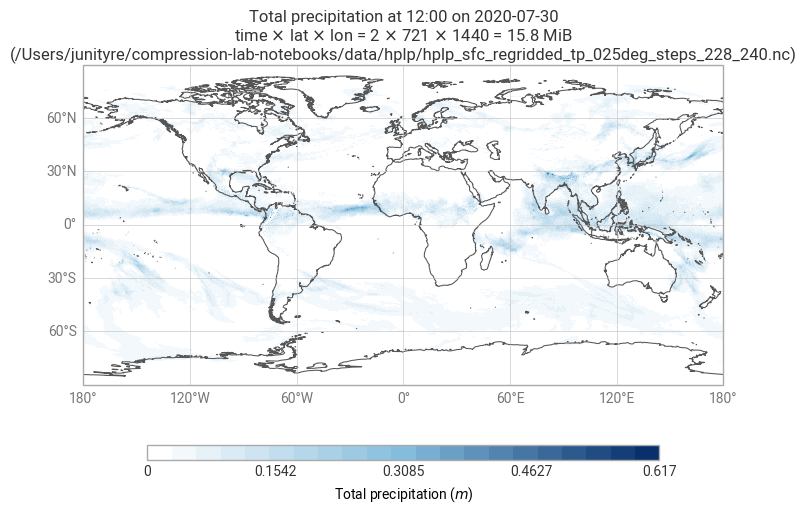

In [6]:
for path in DATASET_PATHS:
    # all example datasets are regridded to regular latitude-longitude grids in NetCDF4 format
    ds = xr.open_dataset(path, engine="netcdf4", decode_timedelta=True)
    # most example datasets only contain a single variable
    if "HOAPS" in path.parent.name == "HOAPS":
        var = "wvpa"
    else:
        (var,) = list(ds)
    da = ds[var]

    quickplot(
        da,
        title=(
            "{default_title}"
            + (
                f"\n{r' $\times$ '.join(da.dims)} = "
                + f"{r' $\times$ '.join(str(s) for s in da.shape)} = "
                + f"{humanize.naturalsize(da.nbytes, binary=True)}"
            )
            + f"\n({path})"
        ),
    )

## Remote access via S3

The data files for the compression laboratory are hosted at [s3://esiwacebucket](https://object-store.os-api.cci1.ecmwf.int/esiwacebucket) and can be accessed using the same path suffixes:

In [7]:
rdata = Path("https://object-store.os-api.cci1.ecmwf.int/esiwacebucket")

REMOTE_DATASET_PATHS = [
    rdata / "HOAPS" / "HOAPS_2020-08_6-hourly.nc",
    rdata / "ICON-XPP" / "ICONXPP_regridded_t_025deg_steps_2026-05_06.nc",
    rdata / "ICON-XPP" / "ICONXPP_regridded_tp_025deg_steps_2026-05_06.nc",
    rdata
    / "NextGEMS_EW3_ICON_ngc4008"
    / "NextGEMS_regridded_hus_025deg_steps_44_45.nc",
    rdata / "NextGEMS_EW3_ICON_ngc4008" / "NextGEMS_regridded_pr_025deg_steps_44_45.nc",
    rdata
    / "OpenIFS"
    / "OpenIFS_pl_regridded_q_025deg_steps_114_120_levels_100_1000.nc",
    rdata / "OpenIFS" / "OpenIFS_sfc_regridded_t_025deg_steps_114_120.nc",
    rdata / "OpenIFS" / "OpenIFS_sfc_regridded_tp_025deg_steps_114_120.nc",
    rdata / "hplp" / "hplp_ml_regridded_q_025deg_levels_10_137_steps_228_240.nc",
    rdata / "hplp" / "hplp_sfc_regridded_t_025deg_levels_steps_204_216_228_240.nc",
    rdata / "hplp" / "hplp_sfc_regridded_t_025deg_steps_228_240.nc",
    rdata / "hplp" / "hplp_sfc_regridded_tp_025deg_steps_228_240.nc",
]

To open the remote files in xarray, you can use the following code:

In [8]:
import xarray as xr
from ipyfilite.http import HTTPFileIO


def open_remote_dataset(url: str, *, engine="h5netcdf", **kwargs) -> xr.Dataset:
    return xr.open_dataset(HTTPFileIO(url, Path(url).name))


ds = open_remote_dataset(
    "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/HOAPS/HOAPS_2020-08_6-hourly.nc"
)